# Figure 3

## Library Imports

In [1]:
import pandas as pd
import numpy as np
import torch
from RnaToProteinDataModule.Dataset_classes import StandardDatasetProcessor
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import seaborn as sns
import sys
import re
import os

## Load and Process Data

**NOTE:** This data was produced via the `RnaToProteinDataModule/scripts/SHAP/2SHAP_horseshoe_plot_generation.py` script. It is reliant on the `0SHAP_run.py` -> `1SHAP_output_consolidation_into_pandas.py` script outputs.

In [2]:
proteins = [
    'CAVIN1',
    'FERMT2',
    'FLNA',
    'HCLS1',
    'HK3',
    'MCM3',
    'MCM4',
    'MCM6',
    'MMP14',
    'P4HB',
    'PTPN6',
    'SMC2',
    'STAT1',
    'VCL',
]

absShapCorrelationDfs = {
    protein: pd.read_csv(f'figure3_datasets/{protein}_shap_vs_spearman.csv', index_col=0) for protein in proteins
}
absShapCorrelationDfs['FLNA']

,absMeanSHAP,spearman,meanSHAP
PRPF38AP2,6.576649e-07,0.241946,4.030028e-07
SFPQP1,7.387221e-08,-0.106089,-5.821433e-09
AL391827.1,2.787397e-08,0.025503,-2.056051e-08
LINC01241,4.377884e-07,0.049942,4.377884e-07
VCAN-AS1,5.683887e-07,0.179527,5.367457e-07
...,...,...,...
DZIP3,8.306927e-06,-0.111743,-3.345860e-06
AL355001.1,6.047405e-07,-0.075411,3.187334e-07
MTND3P6,9.473829e-08,-0.028515,8.191116e-08
SMAD1-AS2,1.788211e-06,-0.179109,3.824178e-07


### Find logs of absolute mean SHAP

In [3]:
def find_log_of_abs_mean_shap(df):
    arr = np.log(df['absMeanSHAP'])
    shapArr = np.array(df['absMeanSHAP'])
    indexArr = np.array(df.index)
    lowest_non_inf = np.min(arr[np.isfinite(arr)])
    arr[np.isinf(arr)] = lowest_non_inf
    arr[np.isneginf(arr)] = lowest_non_inf
    return arr

In [4]:
for key in absShapCorrelationDfs.keys():
    absShapCorrelationDfs[key]['absMeanSHAP'] = find_log_of_abs_mean_shap(absShapCorrelationDfs[key])

/Users/cranneyc/miniforge3/envs/nas_paper/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/cranneyc/miniforge3/envs/nas_paper/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/cranneyc/miniforge3/envs/nas_paper/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/cranneyc/miniforge3/envs/nas_paper/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/cranneyc/miniforge3/envs/nas_paper/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)

## Plots

In [5]:
def plot_and_save(df, filePath, kind):
    plt.clf()
    plt.figure(figsize=(15, 12))
    if kind == 'hex':
        plot = sns.jointplot(data=df, x='spearman', y='absMeanSHAP', kind='hex', cmap="Blues", vmax=250)
    elif kind == 'kde':
        plot = sns.jointplot(data=df, x='spearman', y='absMeanSHAP', kind='kde')
    plot.ax_joint.set_ylim(-25.5, -2)
    plt.xlabel('spearman coefficient', fontsize=24)
    plt.ylabel('abs. mean SHAP (log)', fontsize=24)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '.' + str(x).split('.')[1][0]))
    plt.savefig(filePath, bbox_inches='tight')
    plt.show()

### Loop over all

CAVIN1


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

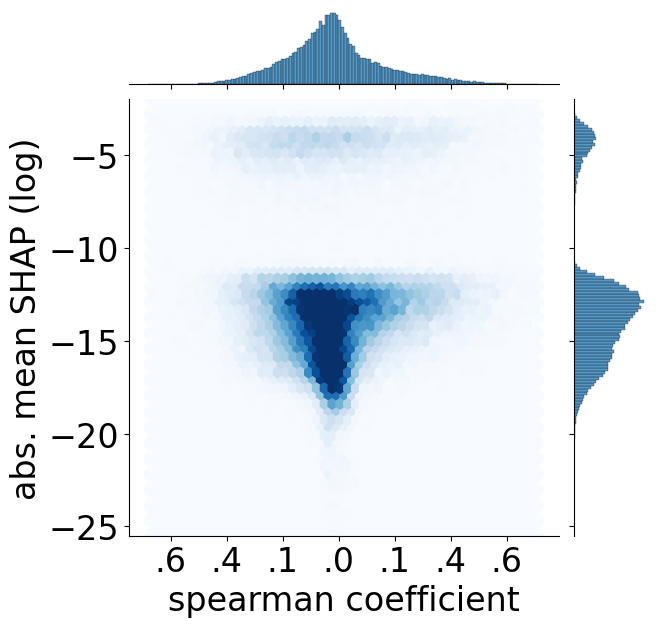

FERMT2


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

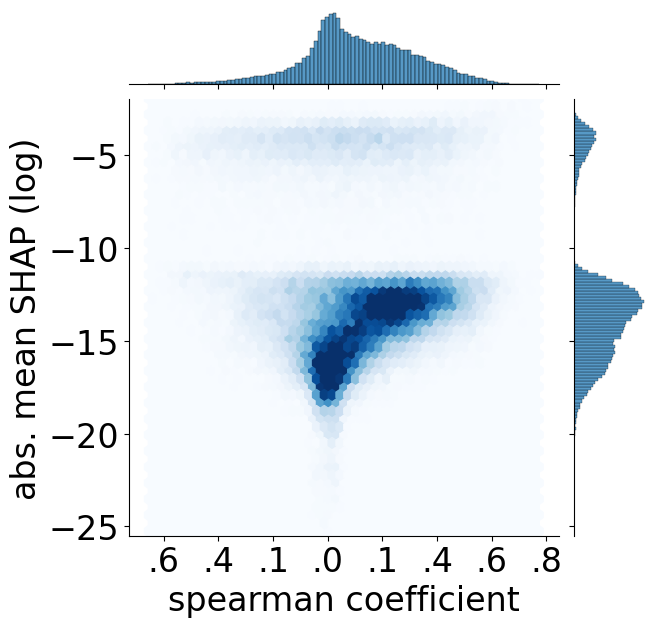

FLNA


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

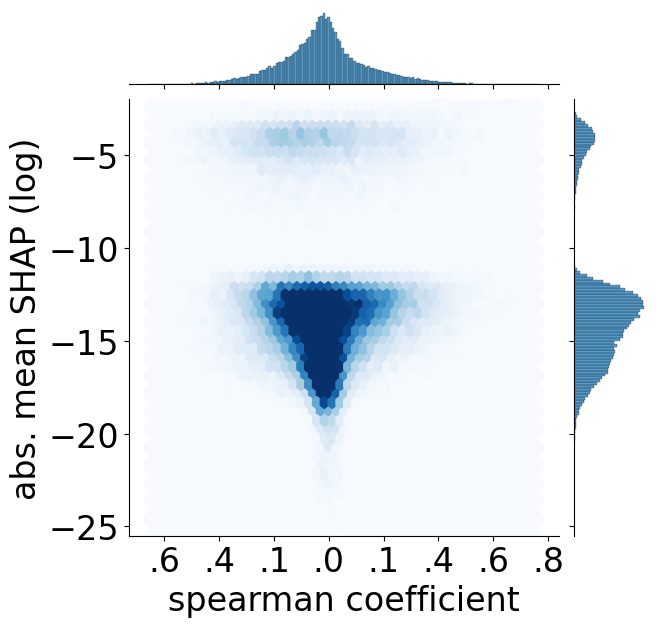

HCLS1


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

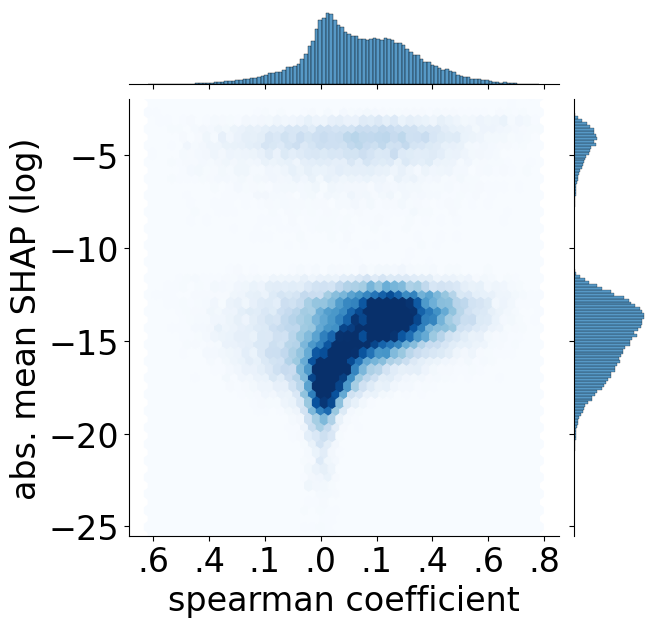

HK3


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

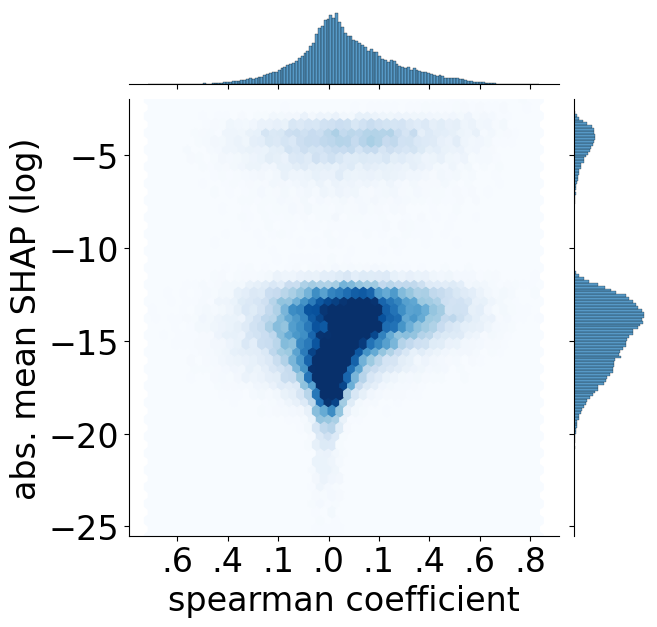

MCM3


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

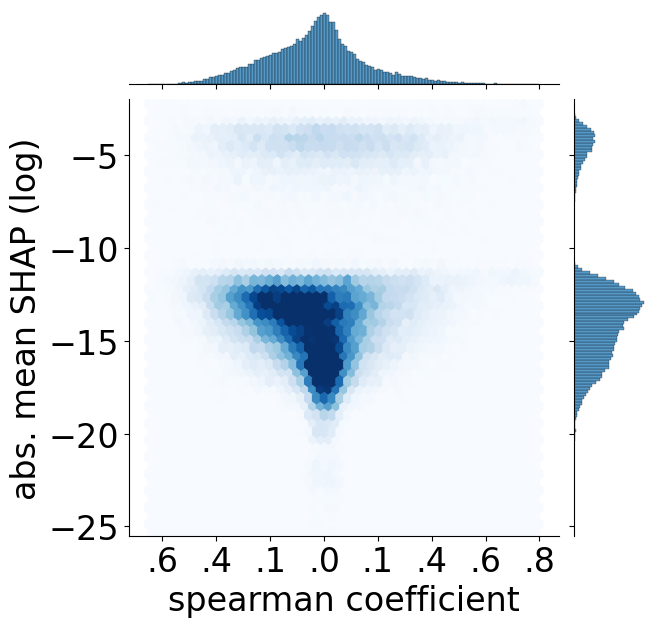

MCM4


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

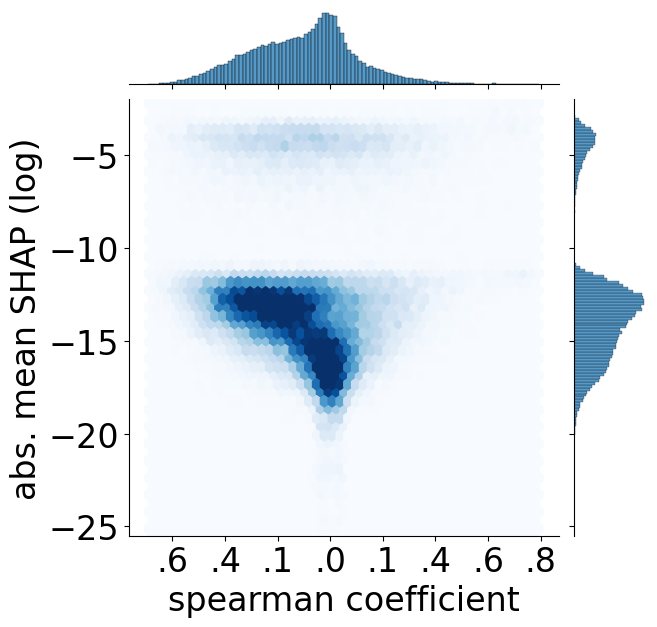

MCM6


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

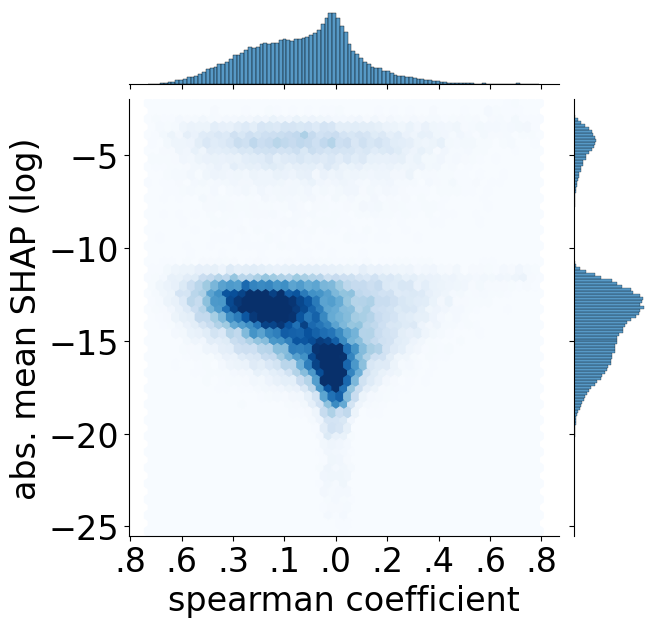

MMP14


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

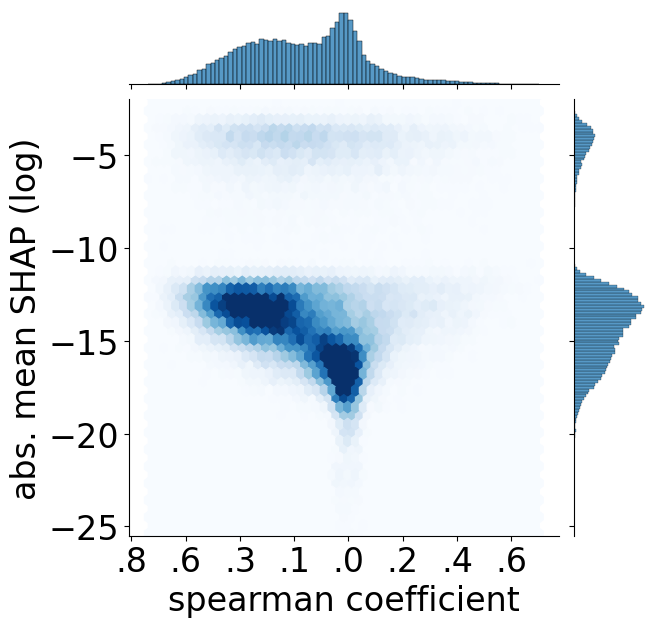

P4HB


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

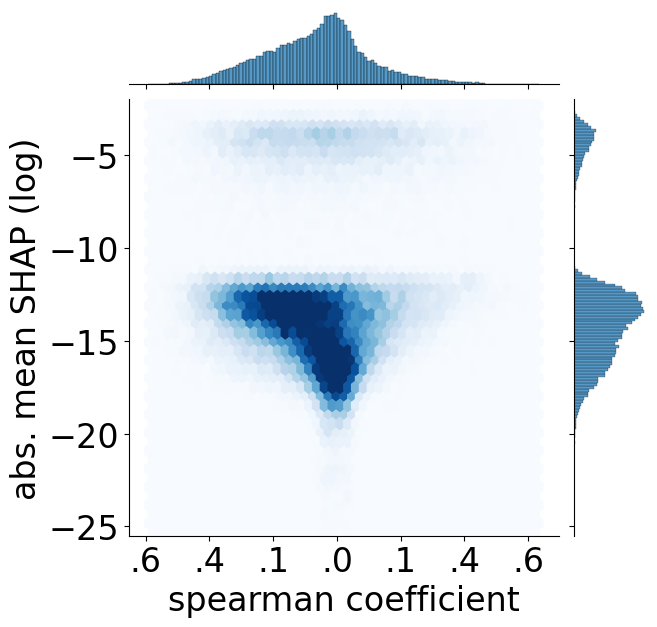

PTPN6


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

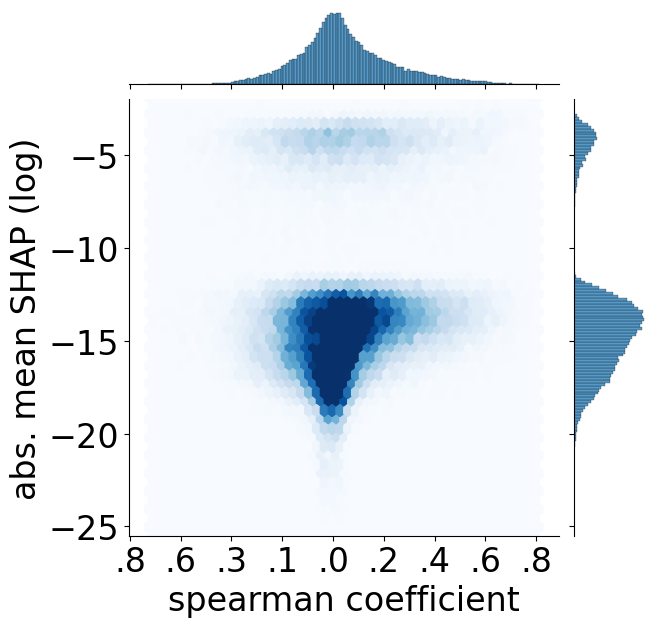

SMC2


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

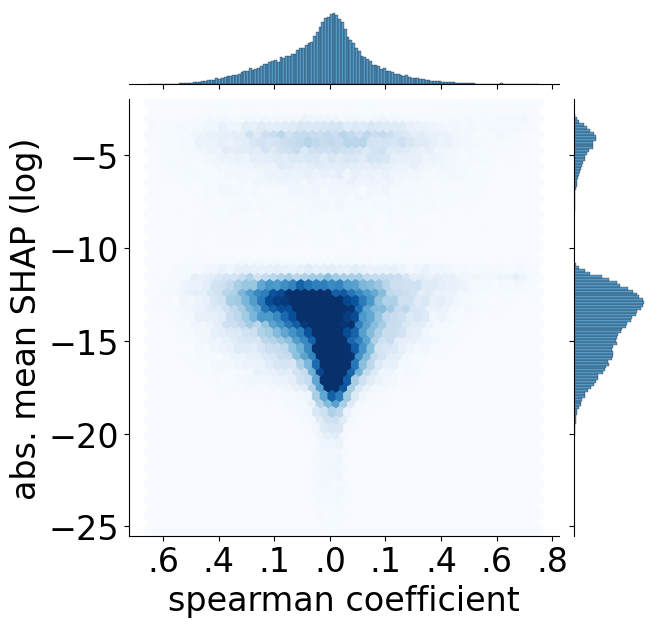

STAT1


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

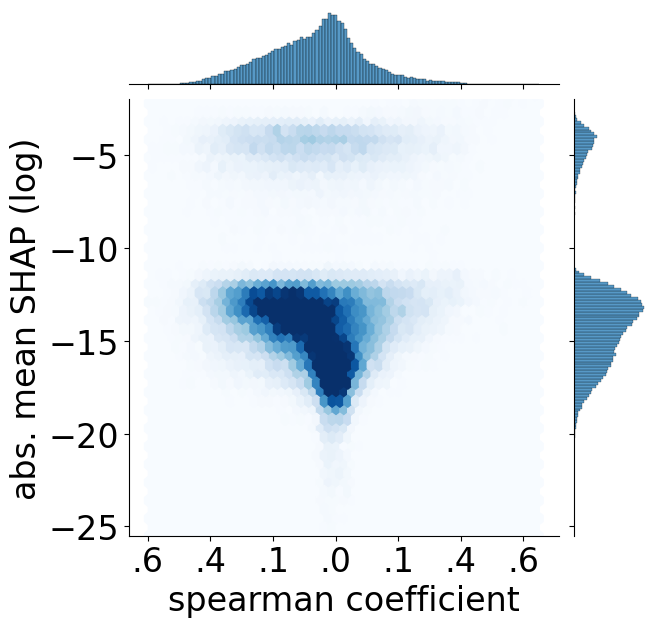

VCL


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

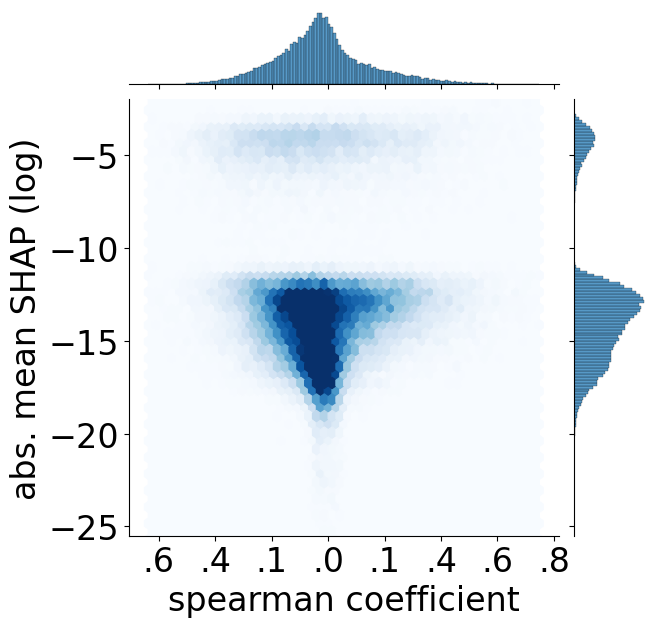

In [6]:
kind = 'hex'
for protein in proteins:
    print(protein)
    plot_and_save(absShapCorrelationDfs[protein], f'figure3_figures/png/{protein}_{kind}.png', kind)

CAVIN1


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

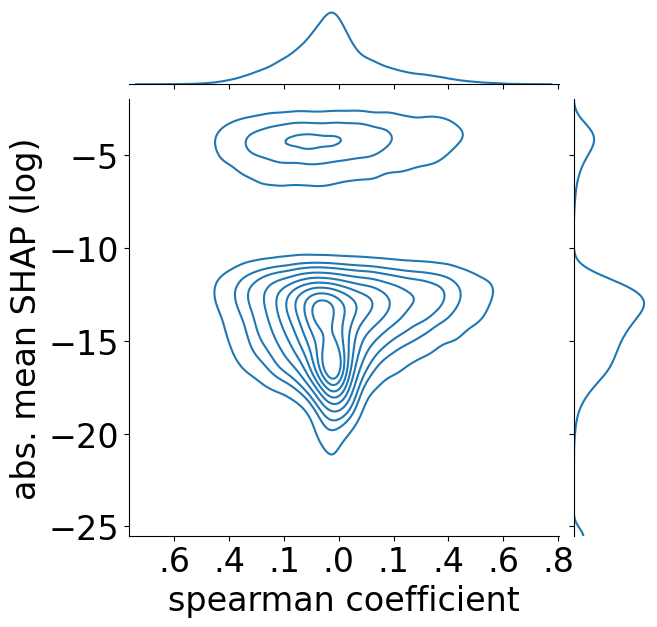

FERMT2


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

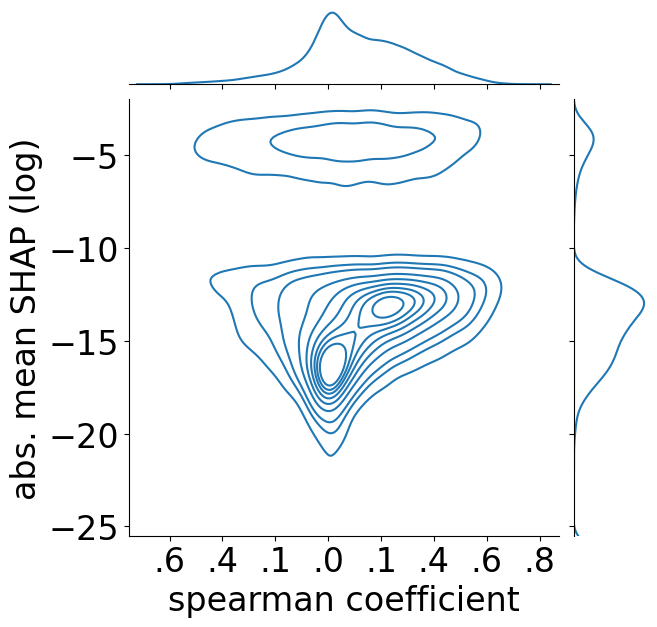

FLNA


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

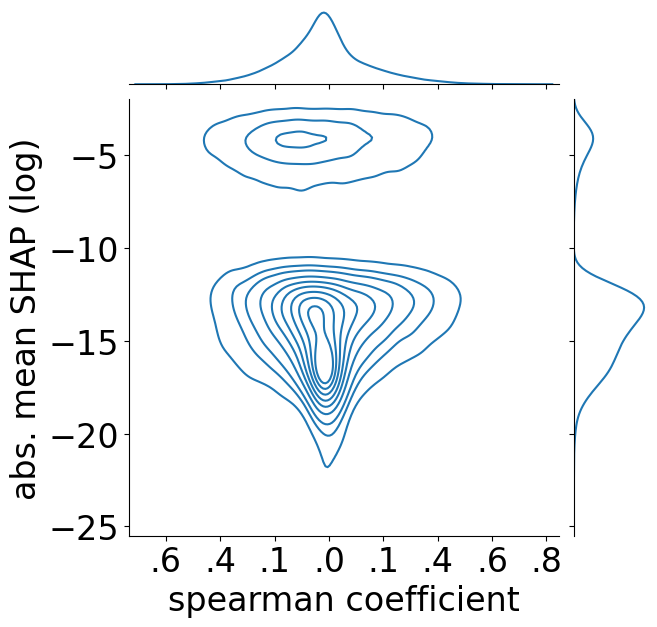

HCLS1


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

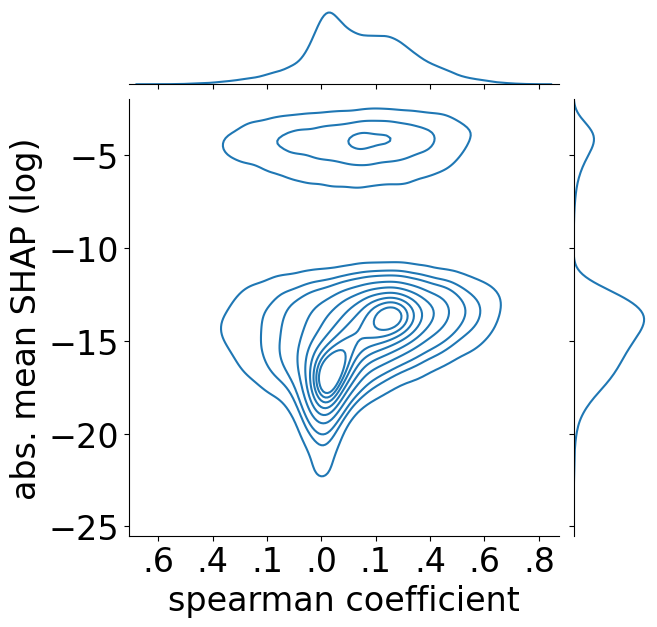

HK3


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

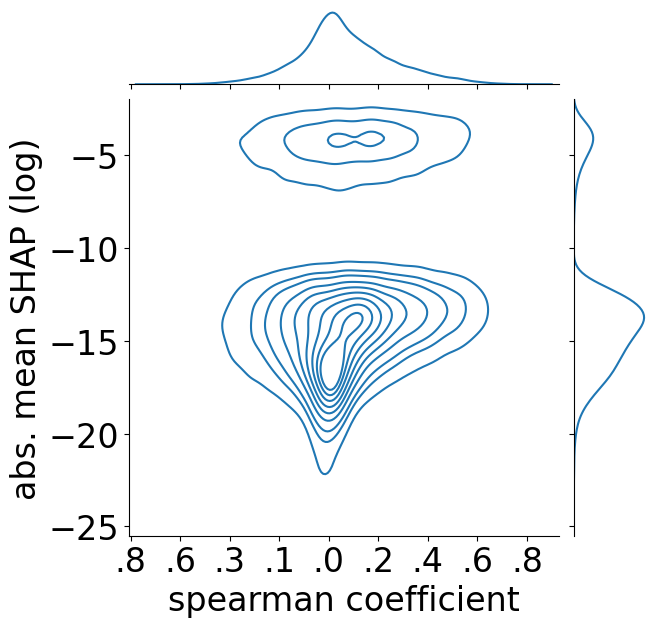

MCM3


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

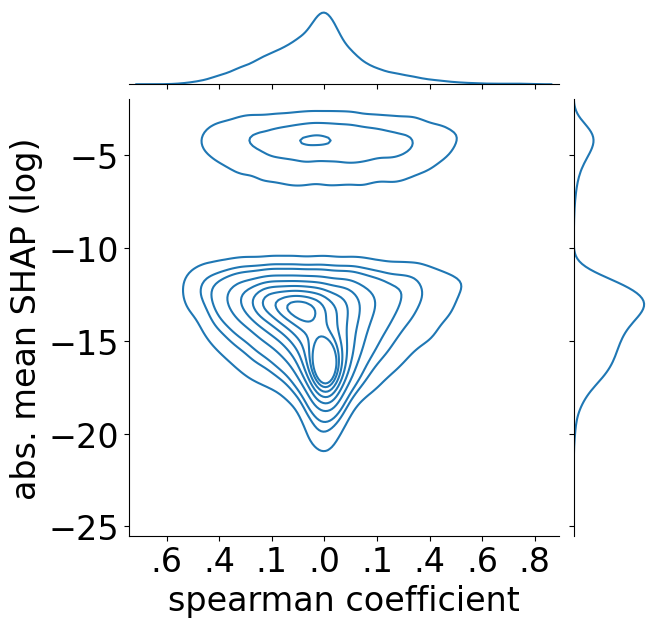

MCM4


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

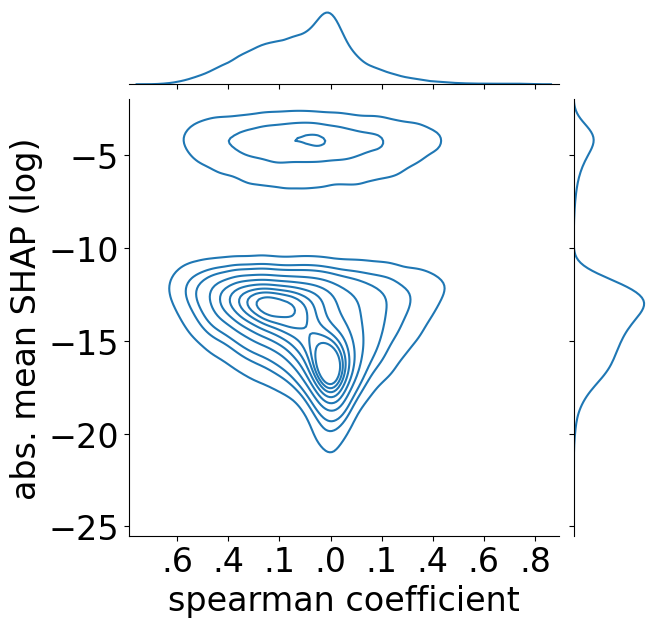

MCM6


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

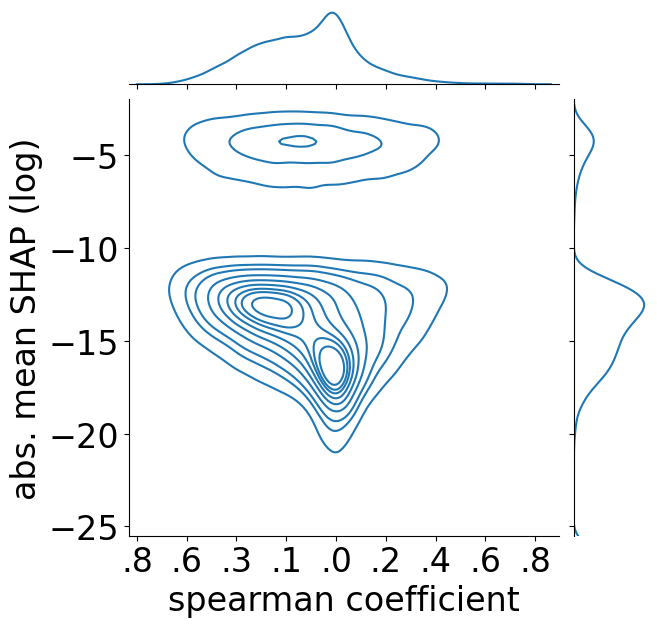

MMP14


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

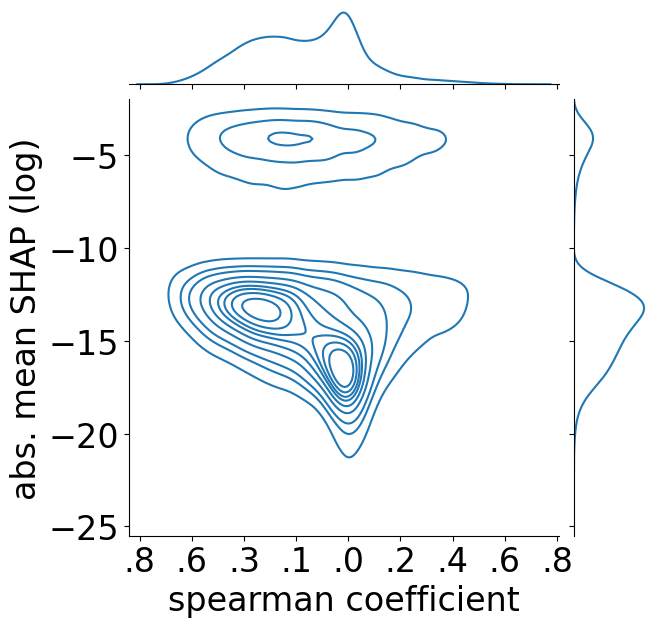

P4HB


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

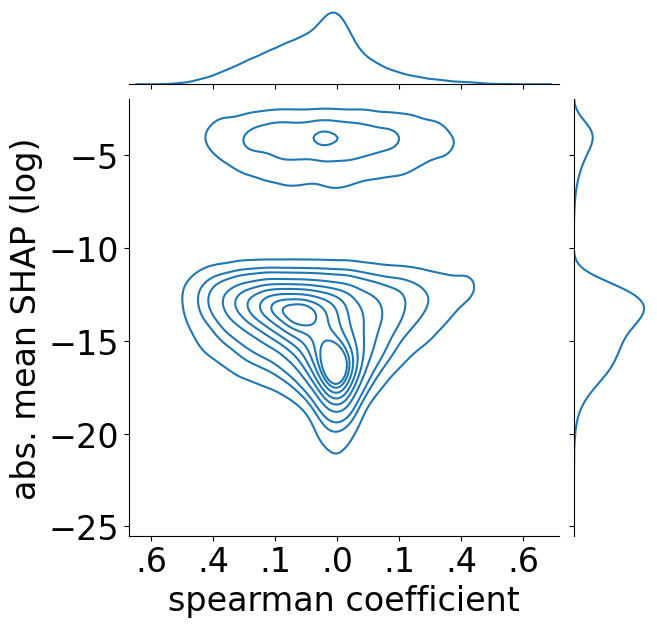

PTPN6


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

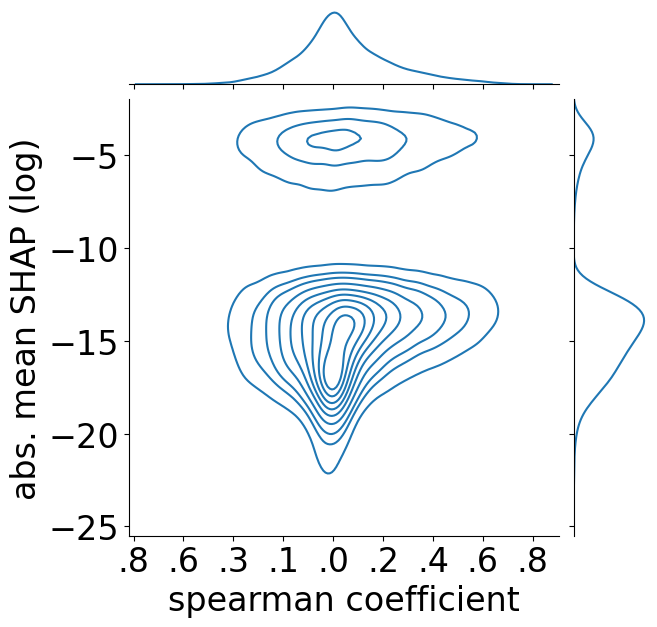

SMC2


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

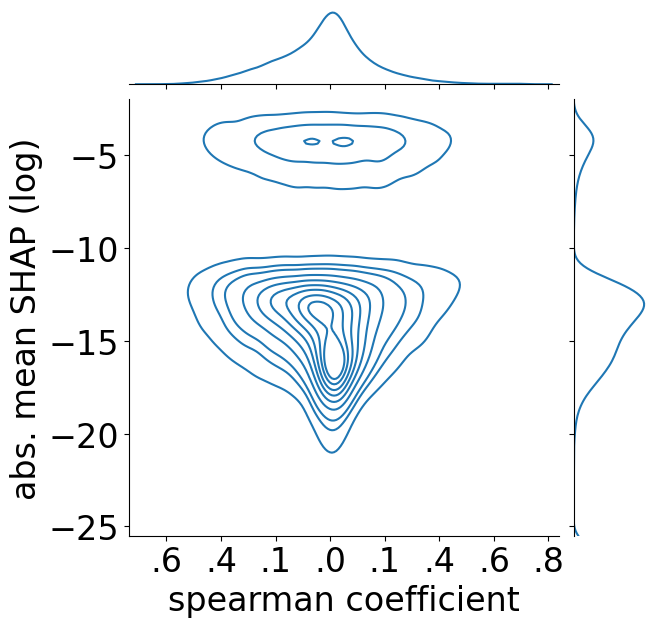

STAT1


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

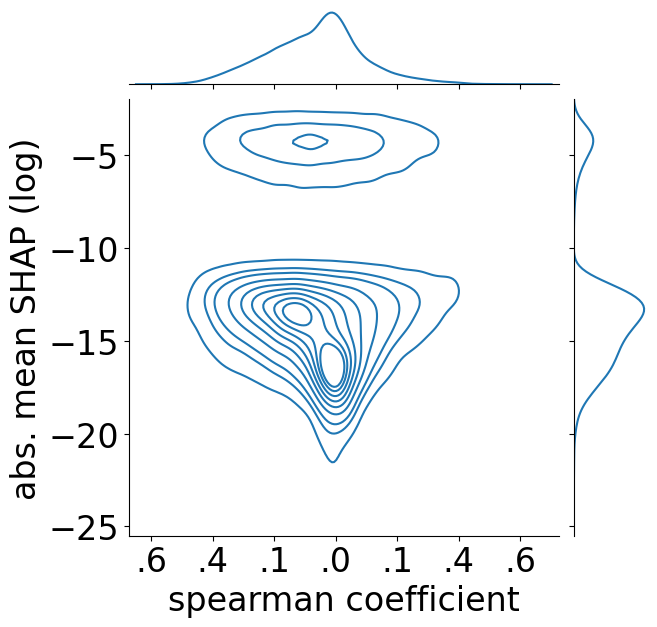

VCL


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

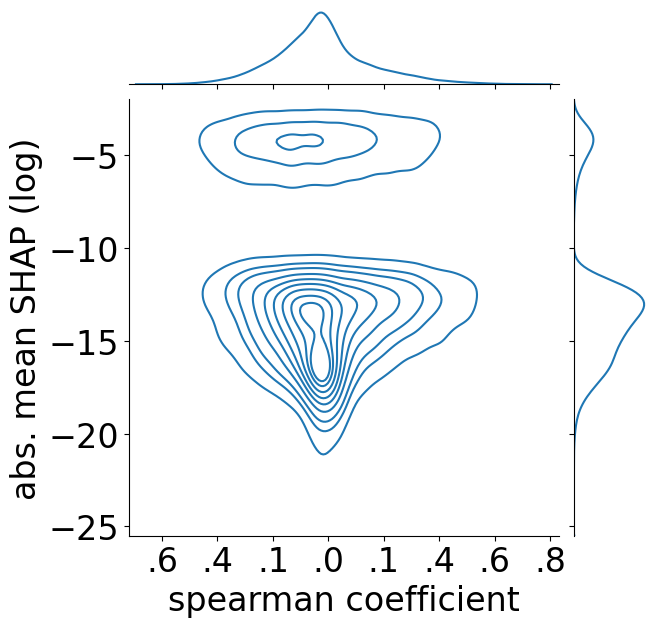

In [7]:
kind = 'kde'
for protein in proteins:
    print(protein)
    plot_and_save(absShapCorrelationDfs[protein], f'figure3_figures/png/{protein}_{kind}.png', kind)